# 12 · Visualization: Box Plots

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Compare the spread of compensation, age and experience across age groups, satisfaction levels, developer types, countries and employment types.

**Data:** Stack Overflow Developer Survey loaded into a SQLite database (table `main`, 65,437 rows)

**Tools:** SQLite, SQL, pandas, Matplotlib

### Key results
- Box plots on a log scale make compensation comparable across groups despite extreme outliers.

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 11](11_viz_histograms.ipynb) · [Project README](../README.md) · [13 →](13_viz_scatter_plots.ipynb)

In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')

## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)

   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


#### Demo 3: Group Data by Age


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)

                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


**Approach:** compensation spans several orders of magnitude, so the box plots use a log scale.

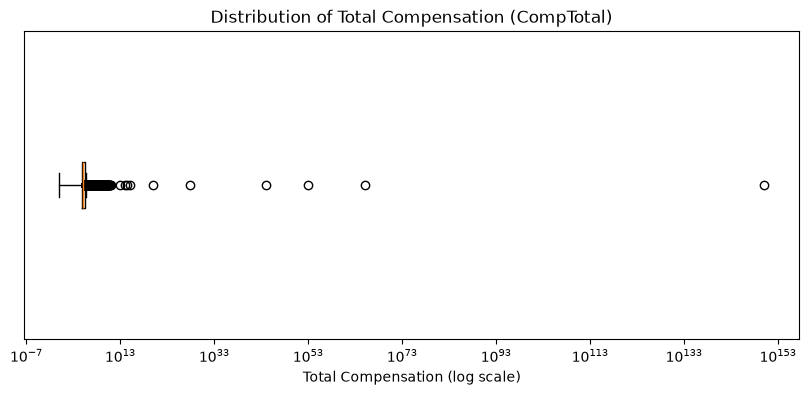

In [19]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL AND CompTotal > 0
"""
df_comp = pd.read_sql_query(QUERY, conn)

# CompTotal has extreme outliers: a log scale keeps the box readable
plt.figure(figsize=(10, 4))
plt.boxplot(df_comp['CompTotal'], orientation='horizontal')
plt.xscale('log')
plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation (log scale)')
plt.yticks([])
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


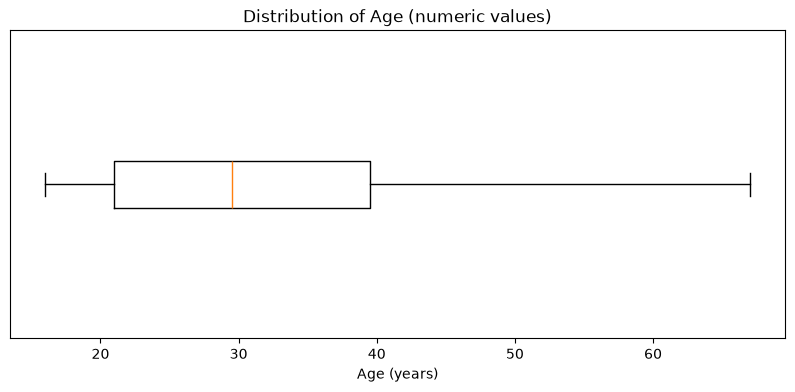

In [20]:
QUERY = """
SELECT Age
FROM main
WHERE Age IS NOT NULL
"""
df_age_num = pd.read_sql_query(QUERY, conn)

# Convert each age range to a numeric value (midpoint of the range)
age_mapping = {'Under 18 years old': 16, '18-24 years old': 21, '25-34 years old': 29.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '55-64 years old': 59.5, '65 years or older': 67}
df_age_num['AgeNumeric'] = df_age_num['Age'].map(age_mapping)
df_age_num = df_age_num.dropna(subset=['AgeNumeric'])

plt.figure(figsize=(10, 4))
plt.boxplot(df_age_num['AgeNumeric'], orientation='horizontal')
plt.title('Distribution of Age (numeric values)')
plt.xlabel('Age (years)')
plt.yticks([])
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


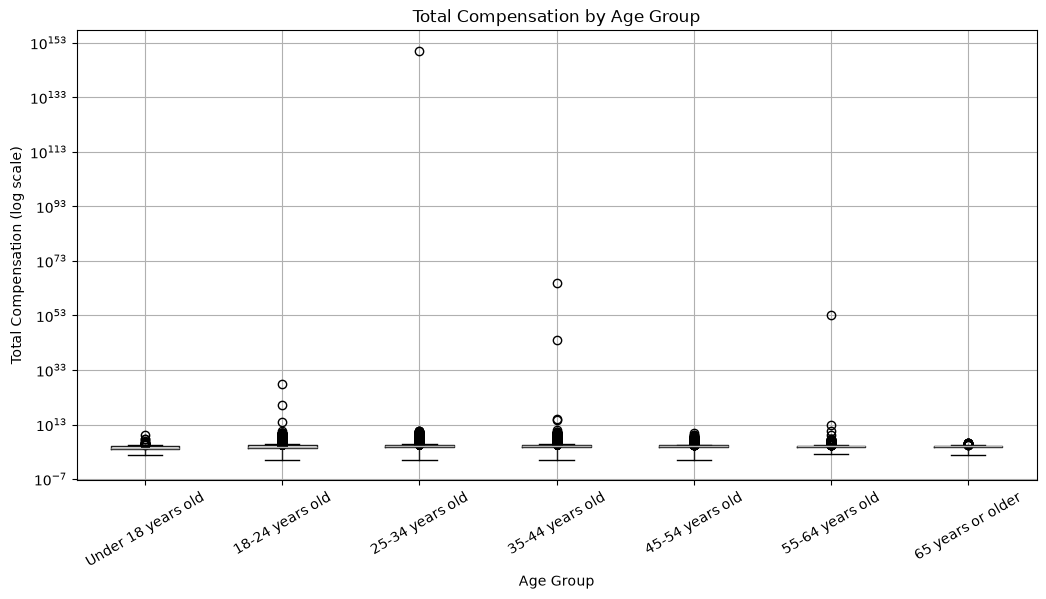

In [12]:
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL AND CompTotal > 0
"""
df_age_comp = pd.read_sql_query(QUERY, conn)

# Order the age groups from youngest to oldest (excluding 'Prefer not to say')
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
df_age_comp = df_age_comp[df_age_comp['Age'].isin(age_order)]
df_age_comp['Age'] = pd.Categorical(df_age_comp['Age'], categories=age_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
df_age_comp.boxplot(column='CompTotal', by='Age', ax=ax, rot=30)
plt.suptitle('')
ax.set_yscale('log')
ax.set_title('Total Compensation by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Total Compensation (log scale)')
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


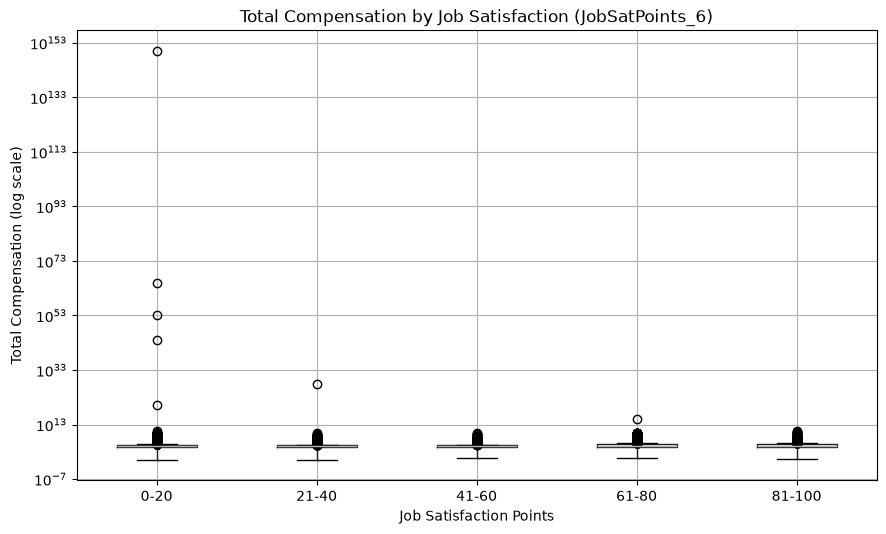

In [13]:
QUERY = """
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE JobSatPoints_6 IS NOT NULL AND CompTotal IS NOT NULL AND CompTotal > 0
"""
df_jobsat = pd.read_sql_query(QUERY, conn)

# Group job satisfaction points into ranges
df_jobsat['JobSatGroup'] = pd.cut(df_jobsat['JobSatPoints_6'], bins=[-1, 20, 40, 60, 80, 100], labels=['0-20', '21-40', '41-60', '61-80', '81-100'])

fig, ax = plt.subplots(figsize=(10, 6))
df_jobsat.boxplot(column='CompTotal', by='JobSatGroup', ax=ax)
plt.suptitle('')
ax.set_yscale('log')
ax.set_title('Total Compensation by Job Satisfaction (JobSatPoints_6)')
ax.set_xlabel('Job Satisfaction Points')
ax.set_ylabel('Total Compensation (log scale)')
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


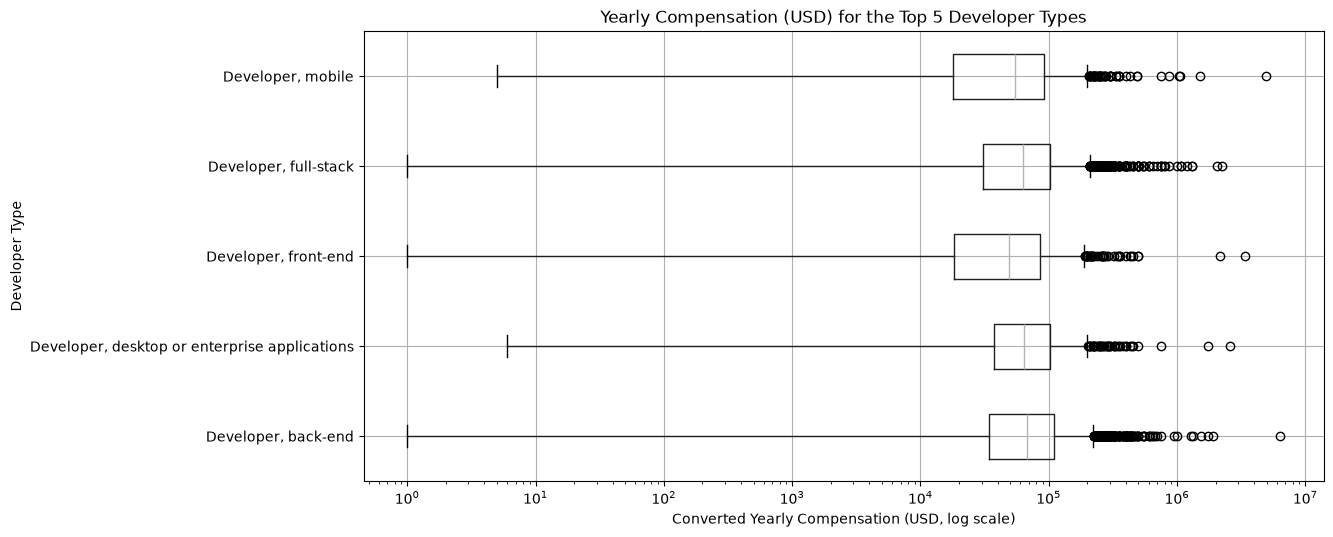

In [14]:
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE DevType IS NOT NULL AND ConvertedCompYearly IS NOT NULL AND ConvertedCompYearly > 0
"""
df_dev = pd.read_sql_query(QUERY, conn)

# Keep only the 5 most common developer types
top5_devtypes = df_dev['DevType'].value_counts().head(5).index
df_top_dev = df_dev[df_dev['DevType'].isin(top5_devtypes)]

fig, ax = plt.subplots(figsize=(12, 6))
df_top_dev.boxplot(column='ConvertedCompYearly', by='DevType', ax=ax, vert=False)
plt.suptitle('')
ax.set_xscale('log')
ax.set_title('Yearly Compensation (USD) for the Top 5 Developer Types')
ax.set_xlabel('Converted Yearly Compensation (USD, log scale)')
ax.set_ylabel('Developer Type')
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


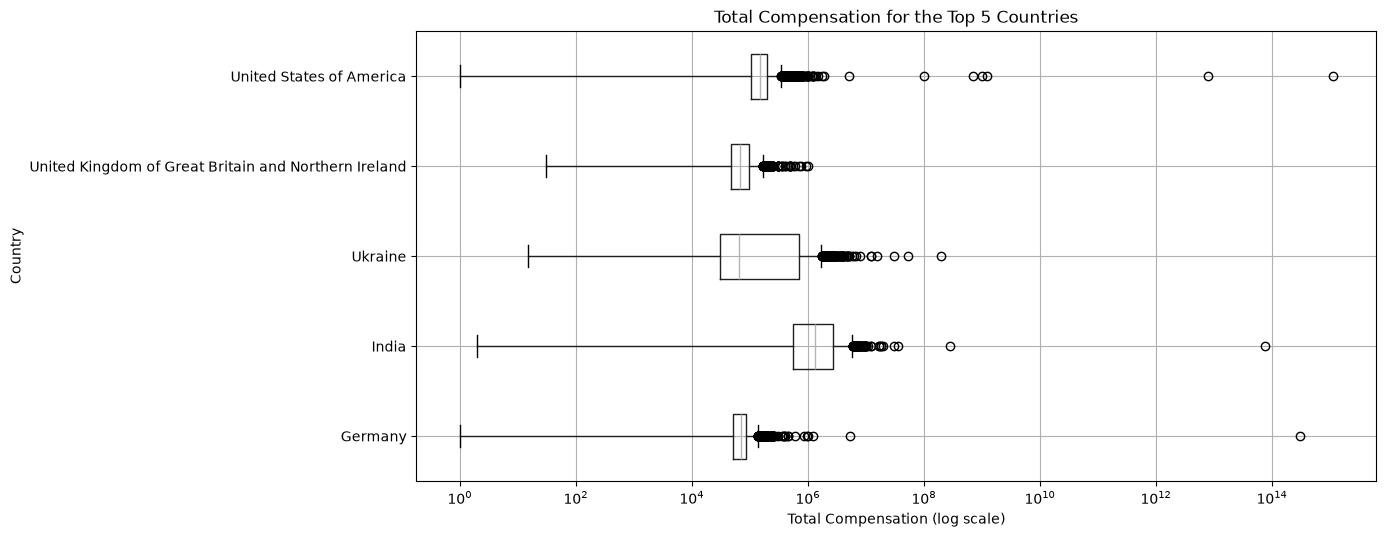

In [7]:
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE Country IS NOT NULL AND CompTotal IS NOT NULL AND CompTotal > 0
"""
df_country = pd.read_sql_query(QUERY, conn)

# Keep only the 5 countries with the most respondents
top5_countries = df_country['Country'].value_counts().head(5).index
df_top_countries = df_country[df_country['Country'].isin(top5_countries)]

fig, ax = plt.subplots(figsize=(12, 6))
df_top_countries.boxplot(column='CompTotal', by='Country', ax=ax, vert=False)
plt.suptitle('')
ax.set_xscale('log')
ax.set_title('Total Compensation for the Top 5 Countries')
ax.set_xlabel('Total Compensation (log scale)')
ax.set_ylabel('Country')
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


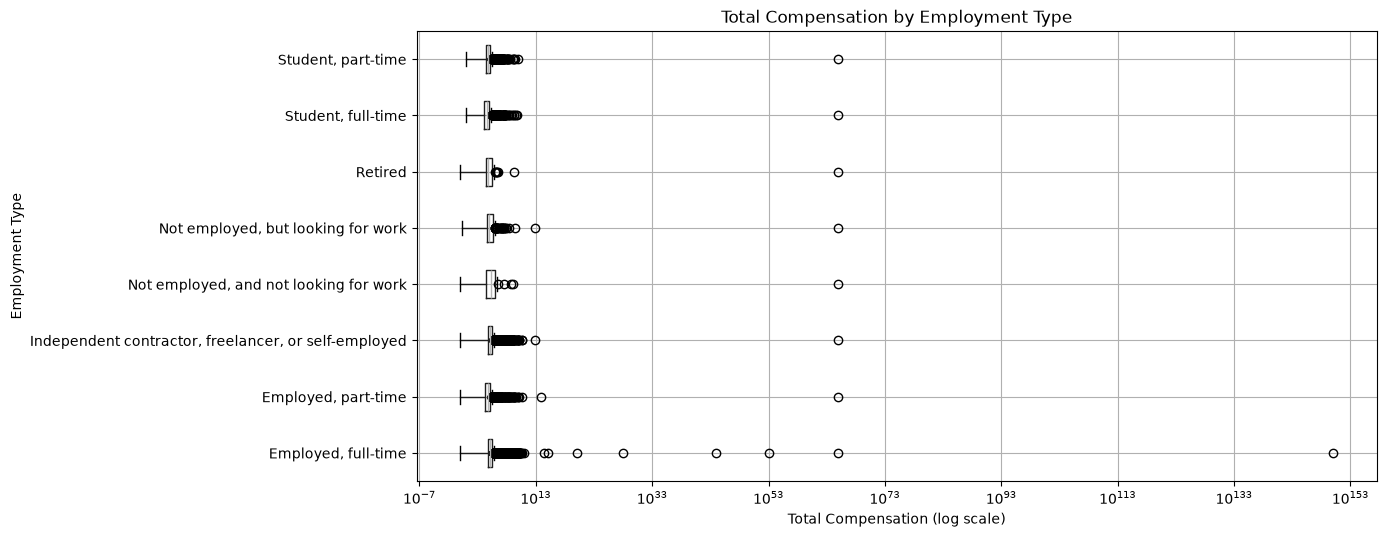

In [8]:
QUERY = """
SELECT Employment, CompTotal
FROM main
WHERE Employment IS NOT NULL AND CompTotal IS NOT NULL AND CompTotal > 0
"""
df_emp = pd.read_sql_query(QUERY, conn)

# Employment is multi-select (separated by ';'): split it into one row per type
df_emp['Employment'] = df_emp['Employment'].str.split(';')
df_emp = df_emp.explode('Employment')

fig, ax = plt.subplots(figsize=(12, 6))
df_emp.boxplot(column='CompTotal', by='Employment', ax=ax, vert=False)
plt.suptitle('')
ax.set_xscale('log')
ax.set_title('Total Compensation by Employment Type')
ax.set_xlabel('Total Compensation (log scale)')
ax.set_ylabel('Employment Type')
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


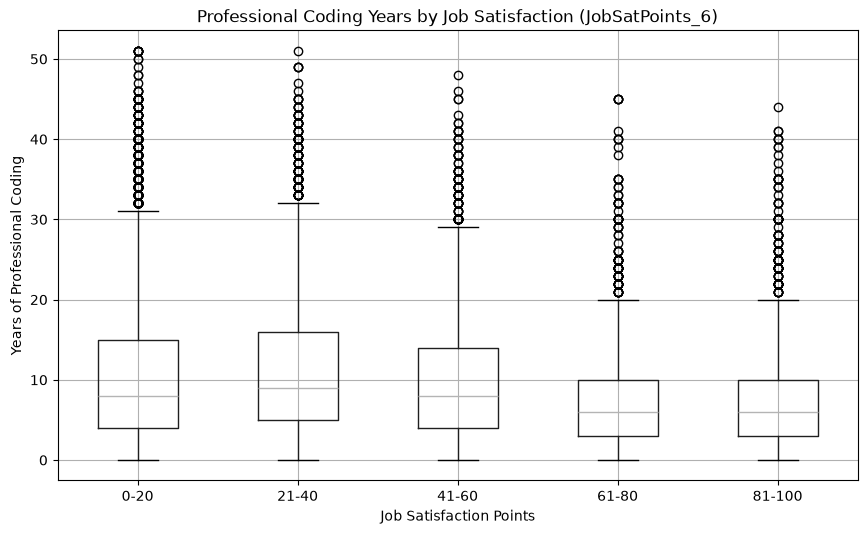

In [15]:
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL
"""
df_ycp = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric values
df_ycp['YearsCodePro'] = df_ycp['YearsCodePro'].replace({'Less than 1 year': '0', 'More than 50 years': '51'})
df_ycp['YearsCodePro'] = pd.to_numeric(df_ycp['YearsCodePro'], errors='coerce')
df_ycp = df_ycp.dropna()

# Group job satisfaction points into ranges
df_ycp['JobSatGroup'] = pd.cut(df_ycp['JobSatPoints_6'], bins=[-1, 20, 40, 60, 80, 100], labels=['0-20', '21-40', '41-60', '61-80', '81-100'])

fig, ax = plt.subplots(figsize=(10, 6))
df_ycp.boxplot(column='YearsCodePro', by='JobSatGroup', ax=ax)
plt.suptitle('')
ax.set_title('Professional Coding Years by Job Satisfaction (JobSatPoints_6)')
ax.set_xlabel('Job Satisfaction Points')
ax.set_ylabel('Years of Professional Coding')
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [21]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
